Paso 1: Cargar todo

In [1]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from features import construir_features, crear_target
from database import cargar_velas
import pandas_ta as ta
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Parámetros
PAR          = "ETHUSDT"
UMBRAL_PROB  = 0.63
STOP_LOSS    = 0.025
TAKE_PROFIT  = 0.010

FEATURES = [
    'close_vs_ema200', 'ema50_vs_ema200',
    'atr_relativo', 'atr_tendencia', 'bb_ancho',
    'rsi', 'adx',
    'hora', 'dia_semana',
    'tendencia_1h', 'rsi_1h', 'adx_1h'
]

print("✅ Librerías cargadas")

✅ Librerías cargadas


Celda 2: Cargar datos y features

In [2]:
# Cargamos velas
df_15m        = cargar_velas("ETHUSDT", "15m")
df_15m['MM']  = ta.ema(df_15m['Close'], length=200)
df_15m['RSI'] = ta.rsi(df_15m['Close'], length=14)
adx           = ta.adx(df_15m['High'], df_15m['Low'],
                       df_15m['Close'], length=14)
df_15m['ADX'] = adx['ADX_14']
sar           = ta.psar(df_15m['High'], df_15m['Low'],
                        df_15m['Close'])
df_15m['SAR'] = sar['PSARl_0.02_0.2'].fillna(
                    sar['PSARs_0.02_0.2'])
df_15m        = df_15m.dropna()

# Features y target
features_df, _ = construir_features("ETHUSDT")
target         = crear_target(
    df_15m.loc[features_df.index],
    stop_loss=STOP_LOSS,
    take_profit=TAKE_PROFIT,
    max_velas=96
)
features_df = features_df.join(target).dropna()

print(f"Velas cargadas:   {len(df_15m):,}")
print(f"Features listas:  {len(features_df):,}")
print(f"\nPrimeras 3 filas de features:")
features_df[FEATURES].head(3)

Cargando datos ETHUSDT...
  15m: 69,886 velas
  1h:  17,322 velas

✅ Features construidas: 69,287 filas x 13 columnas
   Período: 2024-06-10 09:00:00 → 2026-06-02 02:30:00
Velas cargadas:   69,886
Features listas:  69,191

Primeras 3 filas de features:


,close_vs_ema200,ema50_vs_ema200,atr_relativo,atr_tendencia,bb_ancho,rsi,adx,hora,dia_semana,tendencia_1h,rsi_1h,adx_1h
time,,,,,,,,,,,,
2024-06-10 09:00:00,-0.007190,-0.003883,0.002046,-0.054289,0.011722,44.146180,39.853217,9,0,0,43.420764,25.163135
2024-06-10 09:15:00,-0.009408,-0.004009,0.002125,-0.035430,0.011760,38.027334,40.789078,9,0,0,43.420764,25.163135
2024-06-10 09:30:00,-0.007069,-0.004061,0.002245,0.060769,0.011253,45.944930,41.917994,9,0,0,43.420764,25.163135


Celda 3: Entrenar el modelo con la primera ventana

In [3]:
# Usamos la misma lógica que backtesting_ml.py
# Ventana 1: entrenamos con 20% de los datos
n         = len(features_df)
tam_test  = n // 5
fin_train = tam_test * 1
fin_test  = tam_test * 2

f_train = features_df.iloc[:fin_train]
f_test  = features_df.iloc[fin_train:fin_test]

X_train  = f_train[FEATURES]
y_train  = f_train['target']

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X_train)

modelo = LogisticRegression(max_iter=1000,
                            class_weight='balanced')
modelo.fit(X_scaled, y_train)

print(f"Entrenado con: {len(f_train):,} muestras")
print(f"Test con:      {len(f_test):,} muestras")
print(f"Período train: {f_train.index[0].date()} → "
      f"{f_train.index[-1].date()}")
print(f"Período test:  {f_test.index[0].date()} → "
      f"{f_test.index[-1].date()}")

Entrenado con: 13,838 muestras
Test con:      13,838 muestras
Período train: 2024-06-10 → 2024-11-01
Período test:  2024-11-01 → 2025-03-25


Celda 4: Ver las probabilidades vela por vela

In [4]:
# Calculamos probabilidades para el período de test
X_test   = f_test[FEATURES]
X_scaled = scaler.transform(X_test)
probs    = modelo.predict_proba(X_scaled)[:, 1]

# Creamos tabla de decisiones
tabla = pd.DataFrame({
    'fecha':        f_test.index,
    'close':        df_15m.loc[f_test.index, 'Close'].values,
    'prob':         probs.round(3),
    'rsi_1h':       f_test['rsi_1h'].values.round(1),
    'atr_relativo': f_test['atr_relativo'].values.round(4),
    'tendencia_1h': f_test['tendencia_1h'].values.astype(int),
    'decision':     ['🟢 COMPRAR' if p >= UMBRAL_PROB
                     else '🔴 NO operar' for p in probs]
})

print(f"Total velas analizadas: {len(tabla):,}")
print(f"Señales de compra:      "
      f"{(probs >= UMBRAL_PROB).sum():,} "
      f"({(probs >= UMBRAL_PROB).mean()*100:.1f}%)")
print(f"\nMuestra de 20 velas aleatorias:")
tabla.sample(20).sort_values('fecha')

Total velas analizadas: 13,838
Señales de compra:      3,840 (27.7%)

Muestra de 20 velas aleatorias:


,fecha,close,prob,rsi_1h,atr_relativo,tendencia_1h,decision
650,2024-11-08 07:00:00,2894.79,0.698,64.5,0.0048,1,🟢 COMPRAR
759,2024-11-09 10:15:00,3048.60,0.560,70.6,0.0042,1,🔴 NO operar
1066,2024-11-12 15:00:00,3282.49,0.695,46.1,0.0112,1,🟢 COMPRAR
1576,2024-11-17 22:30:00,3060.54,0.627,41.3,0.0059,0,🔴 NO operar
2247,2024-11-24 22:15:00,3350.58,0.400,50.2,0.0039,1,🔴 NO operar
2738,2024-11-30 01:00:00,3584.34,0.626,54.4,0.0039,1,🔴 NO operar
4111,2024-12-14 08:15:00,3924.20,0.490,54.1,0.0024,1,🔴 NO operar
4160,2024-12-14 20:30:00,3840.16,0.368,37.0,0.0036,0,🔴 NO operar
4257,2024-12-15 20:45:00,3892.00,0.423,51.4,0.0026,1,🔴 NO operar
5390,2024-12-27 16:00:00,3319.50,0.547,38.6,0.0059,0,🔴 NO operar


Celda 5: Ver SOLO las operaciones ejecutadas

In [5]:
# Filtramos solo los momentos donde el modelo dijo COMPRAR
señales_compra = tabla[tabla['prob'] >= UMBRAL_PROB].copy()

print(f"Operaciones de compra en el período de test: "
      f"{len(señales_compra):,}")
print(f"\nPrimeras 20 señales de compra:")
señales_compra.head(20)

Operaciones de compra en el período de test: 3,865

Primeras 20 señales de compra:


,fecha,close,prob,rsi_1h,atr_relativo,tendencia_1h,decision
16,2024-11-01 16:30:00,2510.36,0.651,44.7,0.0074,0,🟢 COMPRAR
35,2024-11-01 21:15:00,2496.63,0.633,42.5,0.0052,0,🟢 COMPRAR
36,2024-11-01 21:30:00,2491.80,0.643,42.5,0.0053,0,🟢 COMPRAR
222,2024-11-03 20:00:00,2449.63,0.640,52.8,0.0044,0,🟢 COMPRAR
242,2024-11-04 01:00:00,2452.20,0.680,52.4,0.0039,0,🟢 COMPRAR
243,2024-11-04 01:15:00,2463.40,0.658,52.4,0.0044,0,🟢 COMPRAR
244,2024-11-04 01:30:00,2461.01,0.673,52.4,0.0044,0,🟢 COMPRAR
245,2024-11-04 01:45:00,2466.40,0.653,52.4,0.0044,0,🟢 COMPRAR
246,2024-11-04 02:00:00,2464.07,0.743,58.0,0.0044,0,🟢 COMPRAR
247,2024-11-04 02:15:00,2477.00,0.696,58.0,0.0044,0,🟢 COMPRAR


Celda 6: Ver qué pasó DESPUÉS de cada compra

In [6]:
# Esta es la celda más importante
# Para cada señal de compra, vemos qué pasó con el precio

resultados = []
df_test = df_15m.loc[f_test.index]

for idx, row in señales_compra.head(30).iterrows():
    pos_actual = df_test.index.get_loc(row['fecha'])
    precio_entrada = float(df_test.iloc[pos_actual + 1]['Open']) \
                     if pos_actual + 1 < len(df_test) else None

    if precio_entrada is None:
        continue

    precio_tp = precio_entrada * (1 + TAKE_PROFIT)
    precio_sl = precio_entrada * (1 - STOP_LOSS)

    # Miramos las próximas 96 velas
    resultado = 'TIEMPO'  # si no toca ni TP ni SL
    precio_salida = None
    velas_abiertas = 0

    for j in range(pos_actual + 1,
                   min(pos_actual + 97, len(df_test))):
        vela = df_test.iloc[j]
        velas_abiertas += 1
        if vela['High'] >= precio_tp:
            resultado = '✅ TAKE PROFIT'
            precio_salida = precio_tp
            break
        if vela['Low'] <= precio_sl:
            resultado = '❌ STOP LOSS'
            precio_salida = precio_sl
            break

    if precio_salida:
        ganancia = (precio_salida / precio_entrada - 1) * 100
    else:
        ultimo = float(df_test.iloc[
            min(pos_actual + 96, len(df_test)-1)]['Close'])
        ganancia = (ultimo / precio_entrada - 1) * 100
        precio_salida = ultimo

    resultados.append({
        'fecha_entrada':  pd.to_datetime(row['fecha']).strftime('%Y-%m-%d %H:%M'),
        'precio_entrada': round(precio_entrada, 2),
        'precio_salida':  round(precio_salida, 2),
        'ganancia_%':     round(ganancia, 3),
        'resultado':      resultado,
        'prob_modelo':    round(row['prob'], 3),
        'rsi_1h':         round(row['rsi_1h'], 1),
        'velas_abiertas': velas_abiertas
    })

df_resultados = pd.DataFrame(resultados)
print(f"Operaciones analizadas: {len(df_resultados)}")
print(f"Ganadoras:  "
      f"{len(df_resultados[df_resultados['ganancia_%'] > 0])}")
print(f"Perdedoras: "
      f"{len(df_resultados[df_resultados['ganancia_%'] <= 0])}")
print()
df_resultados

Operaciones analizadas: 30
Ganadoras:  17
Perdedoras: 13



,fecha_entrada,precio_entrada,precio_salida,ganancia_%,resultado,prob_modelo,rsi_1h,velas_abiertas
0,2024-11-01 16:30,2510.36,2494.14,-0.646,TIEMPO,0.651,44.7,96
1,2024-11-01 21:15,2496.64,2521.61,1.000,✅ TAKE PROFIT,0.633,42.5,20
2,2024-11-01 21:30,2491.80,2516.72,1.000,✅ TAKE PROFIT,0.643,42.5,7
3,2024-11-03 20:00,2449.63,2474.13,1.000,✅ TAKE PROFIT,0.640,52.8,4
4,2024-11-04 01:00,2452.20,2476.72,1.000,✅ TAKE PROFIT,0.680,52.4,5
5,2024-11-04 01:15,2463.39,2488.02,1.000,✅ TAKE PROFIT,0.658,52.4,7
6,2024-11-04 01:30,2461.01,2485.62,1.000,✅ TAKE PROFIT,0.673,52.4,6
7,2024-11-04 01:45,2466.40,2491.06,1.000,✅ TAKE PROFIT,0.653,52.4,5
8,2024-11-04 02:00,2464.06,2488.70,1.000,✅ TAKE PROFIT,0.743,58.0,4
9,2024-11-04 02:15,2477.00,2415.07,-2.500,❌ STOP LOSS,0.696,58.0,58


Celda 7: Gráfico de una operación específica

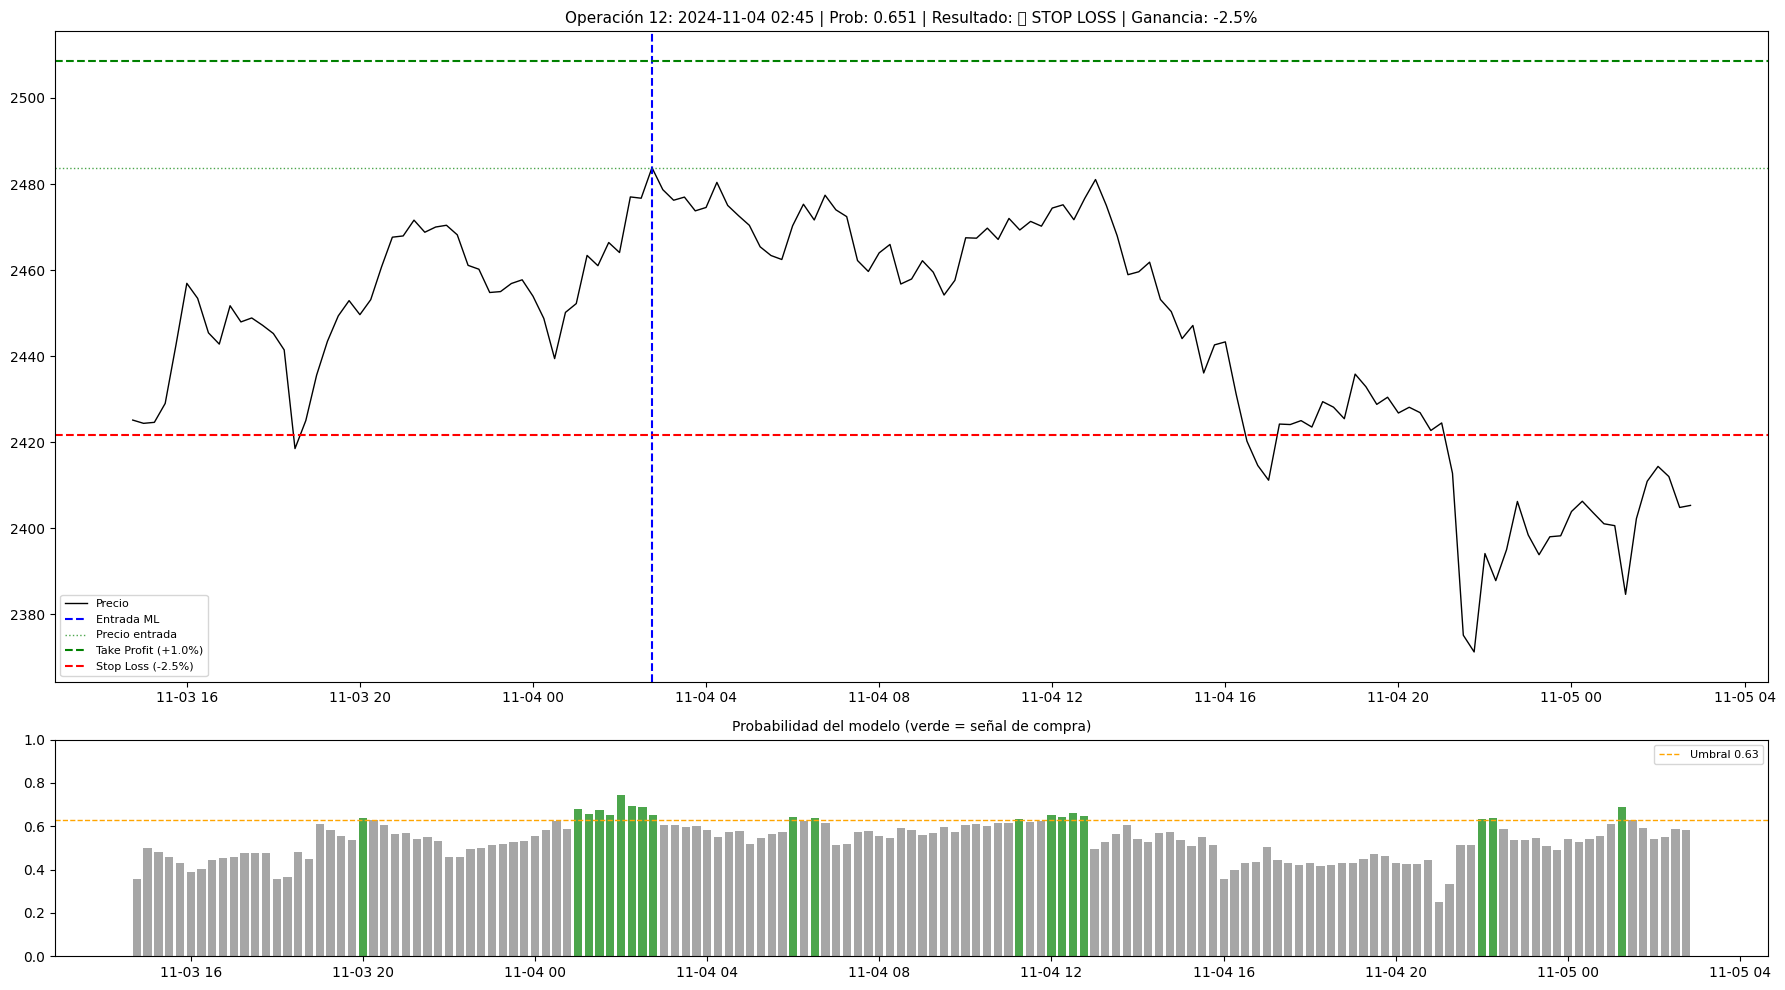


Detalle de la operación 12:
  Fecha entrada:   2024-11-04 02:45
  Precio entrada:  $2483.79
  Precio salida:   $2421.7
  Resultado:       ❌ STOP LOSS
  Ganancia:        -2.5%
  Prob. modelo:    0.651
  RSI 1h:          58.0
  Velas abiertas:  55 (13h 45min)


In [13]:
# Elegí cualquier número de operación para verla en detalle
N_OPERACION = 11  # cambiá este número para ver otras

op = df_resultados.iloc[N_OPERACION]
fecha_entrada = pd.to_datetime(op['fecha_entrada'])

# Tomamos 48 velas antes y 96 después
pos = df_test.index.get_loc(
    df_test.index[df_test.index >= fecha_entrada][0]
)
inicio = max(0, pos - 48)
fin    = min(len(df_test), pos + 97)
df_plot = df_test.iloc[inicio:fin]

fig, axs = plt.subplots(2, 1, figsize=(18, 10),
                        gridspec_kw={'height_ratios': [3, 1]})

# Panel precio
axs[0].plot(df_plot.index, df_plot['Close'],
            lw=1, color='black', label='Precio')
axs[0].axvline(fecha_entrada, color='blue',
               lw=1.5, ls='--', label='Entrada ML')
axs[0].axhline(op['precio_entrada'], color='green',
               lw=1, ls=':', alpha=0.7, label='Precio entrada')
axs[0].axhline(op['precio_entrada'] * (1 + TAKE_PROFIT),
               color='green', lw=1.5, ls='--',
               label=f'Take Profit (+{TAKE_PROFIT*100}%)')
axs[0].axhline(op['precio_entrada'] * (1 - STOP_LOSS),
               color='red', lw=1.5, ls='--',
               label=f'Stop Loss (-{STOP_LOSS*100}%)')
axs[0].set_title(
    f"Operación {N_OPERACION+1}: "
    f"{op['fecha_entrada']} | "
    f"Prob: {op['prob_modelo']} | "
    f"Resultado: {op['resultado']} | "
    f"Ganancia: {op['ganancia_%']}%",
    fontsize=11
)
axs[0].legend(fontsize=8)

# Panel probabilidades del modelo
probs_plot = probs[inicio:fin]
colores    = ['green' if p >= UMBRAL_PROB else 'gray'
              for p in probs_plot]
axs[1].bar(df_plot.index, probs_plot,
           color=colores, alpha=0.7, width=0.008)
axs[1].axhline(UMBRAL_PROB, color='orange',
               lw=1, ls='--', label=f'Umbral {UMBRAL_PROB}')
axs[1].set_title("Probabilidad del modelo (verde = señal de compra)",
                 fontsize=10)
axs[1].set_ylim(0, 1)
axs[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nDetalle de la operación {N_OPERACION+1}:")
print(f"  Fecha entrada:   {op['fecha_entrada']}")
print(f"  Precio entrada:  ${op['precio_entrada']}")
print(f"  Precio salida:   ${op['precio_salida']}")
print(f"  Resultado:       {op['resultado']}")
print(f"  Ganancia:        {op['ganancia_%']}%")
print(f"  Prob. modelo:    {op['prob_modelo']}")
print(f"  RSI 1h:          {op['rsi_1h']}")
print(f"  Velas abiertas:  {op['velas_abiertas']} "
      f"({op['velas_abiertas']*15//60}h {op['velas_abiertas']*15%60}min)")